<h1 style="text-align:center; font-weight: bold;">Anemia Prediction Analysis</h1> 

## **EDA and Visualization Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import time
 
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

## **Data**

In [3]:
data = pd.read_csv('ANERBC_CORELAB_152K_20240603_R01.csv')
data

,Age,Gender,Hemoglobin(g/dL),Hematocrit(fL),RBC(mil/uL),MCV(fL),MCH(pg),MCHC(g/dL),RDW(fL),Serum_Iron(ug/dL),Ferritin(ng/mL),TIBC(ug/dL),Vitamin_B12(pg/mL),Folate(ng/mL),CRP(mg/L),WBC(10*3/uL),Platelets(10*3/uL),Result
0,43,1,17.22,31.75860,6.15,76.54,28.15,33.81,9.881314,91.10,46.31,288.19,444.09,6.58,7.71,7.91,321.53,0
1,23,0,10.45,10.50282,3.33,86.62,33.39,32.81,9.900666,68.68,113.89,326.61,564.58,9.54,0.23,4.82,251.98,1
2,73,1,11.94,14.77844,4.12,94.14,29.69,34.04,12.643002,59.59,49.61,336.92,462.40,11.12,5.49,6.93,287.01,1
3,32,0,14.92,23.87705,5.35,80.23,23.16,32.76,10.189210,73.98,400.00,292.48,355.74,5.16,5.21,5.60,285.42,0
4,46,0,11.04,12.15324,3.96,84.61,30.07,36.94,12.649195,61.06,5.00,306.00,564.46,7.92,1.55,6.96,372.37,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153723,54,1,9.90,10.24445,3.31,83.35,30.43,31.74,12.185770,120.11,58.56,346.25,582.07,2.00,2.68,6.07,362.32,1
153724,35,0,11.85,13.90158,3.74,95.42,27.11,31.50,12.328264,20.00,108.15,353.69,443.81,6.59,0.47,7.23,215.21,1
153725,63,1,15.21,25.52394,5.59,81.07,26.89,33.80,10.936343,97.58,109.29,310.10,397.95,8.00,2.29,7.41,126.79,0
153726,1,1,14.11,22.30613,4.91,86.85,30.67,31.38,10.109340,127.54,192.23,285.69,427.60,10.63,0.57,5.91,230.14,0


## **Data Summary**

In [4]:
data.shape

(153728, 18)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153728 entries, 0 to 153727
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 153728 non-null  int64  
 1   Gender              153728 non-null  int64  
 2   Hemoglobin(g/dL)    153728 non-null  float64
 3   Hematocrit(fL)      153728 non-null  float64
 4   RBC(mil/uL)         153728 non-null  float64
 5   MCV(fL)             153728 non-null  float64
 6   MCH(pg)             153728 non-null  float64
 7   MCHC(g/dL)          153728 non-null  float64
 8   RDW(fL)             153728 non-null  float64
 9   Serum_Iron(ug/dL)   153728 non-null  float64
 10  Ferritin(ng/mL)     153728 non-null  float64
 11  TIBC(ug/dL)         153728 non-null  float64
 12  Vitamin_B12(pg/mL)  153728 non-null  float64
 13  Folate(ng/mL)       153728 non-null  float64
 14  CRP(mg/L)           153728 non-null  float64
 15  WBC(10*3/uL)        153728 non-nul

In [6]:
data.describe()

,Age,Gender,Hemoglobin(g/dL),Hematocrit(fL),RBC(mil/uL),MCV(fL),MCH(pg),MCHC(g/dL),RDW(fL),Serum_Iron(ug/dL),Ferritin(ng/mL),TIBC(ug/dL),Vitamin_B12(pg/mL),Folate(ng/mL),CRP(mg/L),WBC(10*3/uL),Platelets(10*3/uL),Result
count,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000,153728.000000
mean,34.744789,0.500891,13.080430,17.990929,4.472621,87.990448,29.394619,33.410551,11.688146,83.917006,118.502828,311.478456,433.595981,8.296569,2.997003,7.267029,257.460906,0.346931
std,17.494816,0.500001,2.121211,5.670851,0.775827,6.996692,3.118656,1.840343,1.371263,31.113583,69.339598,44.685955,146.202088,2.586087,2.991113,1.811110,59.824089,0.475995
min,1.000000,0.000000,6.000000,3.600000,2.000000,65.000000,20.000000,28.000000,6.812118,20.000000,5.000000,200.000000,120.000000,2.000000,0.100000,3.000000,120.000000,0.000000
25%,22.000000,0.000000,11.770000,14.073560,3.980000,83.270000,27.250000,32.150000,10.737530,62.250000,66.910000,280.870000,333.800000,6.560000,0.860000,6.030000,216.400000,0.000000
50%,35.000000,1.000000,13.250000,17.920715,4.520000,87.970000,29.310000,33.340000,11.628903,83.970000,116.870000,310.130000,435.690000,8.310000,2.070000,7.250000,257.415000,0.000000
75%,47.000000,1.000000,14.570000,21.789300,5.010000,92.720000,31.430000,34.590000,12.577586,105.210000,166.270000,340.920000,533.570000,10.060000,4.170000,8.480000,297.910000,1.000000
max,90.000000,1.000000,18.000000,39.274950,7.160000,110.000000,38.000000,38.000000,18.249502,200.000000,400.000000,450.000000,900.000000,19.350000,25.000000,16.130000,511.670000,1.000000


## **Missing values check**

In [7]:
data.isnull().sum()

Age                   0
Gender                0
Hemoglobin(g/dL)      0
Hematocrit(fL)        0
RBC(mil/uL)           0
MCV(fL)               0
MCH(pg)               0
MCHC(g/dL)            0
RDW(fL)               0
Serum_Iron(ug/dL)     0
Ferritin(ng/mL)       0
TIBC(ug/dL)           0
Vitamin_B12(pg/mL)    0
Folate(ng/mL)         0
CRP(mg/L)             0
WBC(10*3/uL)          0
Platelets(10*3/uL)    0
Result                0
dtype: int64

## **Target Variable Distribution**

In [8]:
counts = data['Result'].value_counts().sort_index()
labels = ['No Anemia', 'Anemia']
print(counts)

Result
0    100395
1     53333
Name: count, dtype: int64


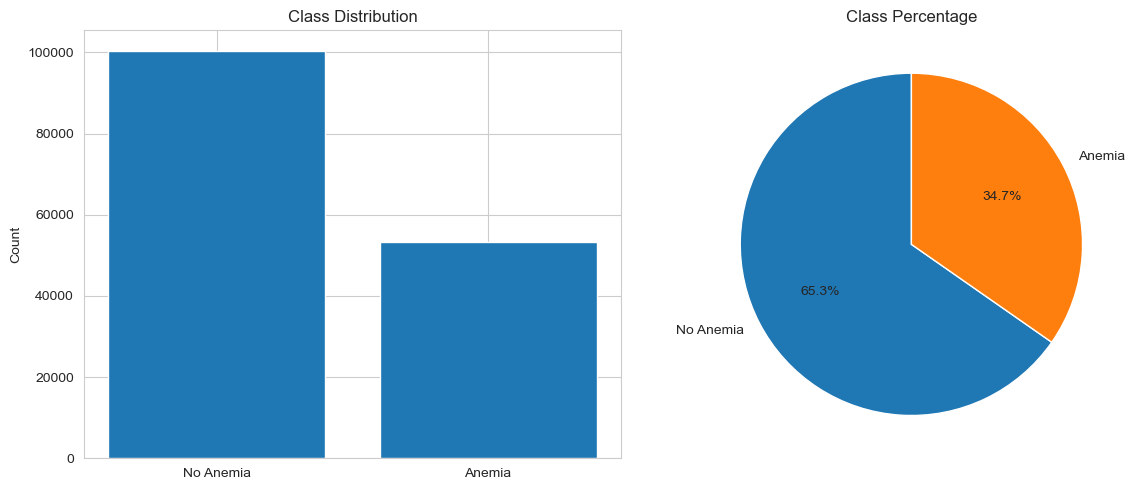

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].bar(labels, counts)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
 
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Percentage')
 
plt.tight_layout()
plt.show()

## **Gender Distribution vs Result**

In [10]:
gender_counts = data['Gender'].value_counts()
print(f"Male (1): {gender_counts.get(1, 0)}")
print(f"Female (0): {gender_counts.get(0, 0)}")
 
gender_anemia = pd.crosstab(data['Gender'], data['Result'], normalize='index') * 100
print("\nAnemia Rate by Gender:")
print(gender_anemia)

Male (1): 77001
Female (0): 76727

Anemia Rate by Gender:
Result          0          1
Gender                      
0       60.730903  39.269097
1       69.866625  30.133375


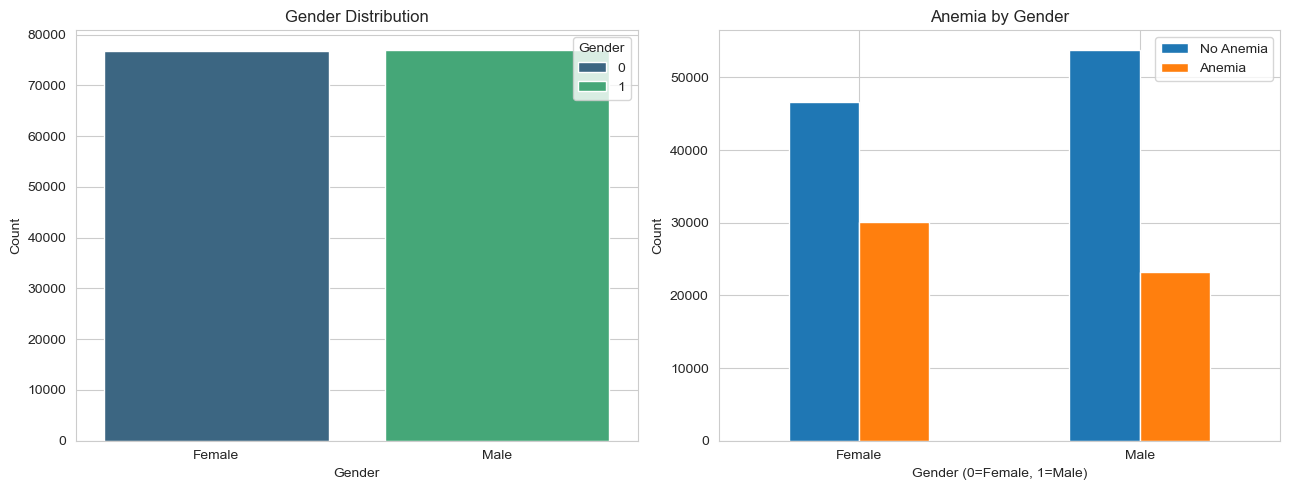

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
sns.countplot(data=data, x='Gender', hue='Gender', ax=axes[0], palette='viridis')
axes[0].set_title('Gender Distribution')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Female', 'Male'])
axes[0].set_ylabel('Count')
 
pd.crosstab(data['Gender'], data['Result']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Anemia by Gender')
axes[1].set_xlabel('Gender (0=Female, 1=Male)')
axes[1].set_ylabel('Count')
axes[1].legend(['No Anemia', 'Anemia'])
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
 
plt.tight_layout()
plt.show()

## **Age Distribution**

In [12]:
print(f"Age Range: {data['Age'].min()} - {data['Age'].max()} years")
print(f"Mean Age: {data['Age'].mean():.2f} years")
print(f"Median Age: {data['Age'].median():.2f} years")

Age Range: 1 - 90 years
Mean Age: 34.74 years
Median Age: 35.00 years


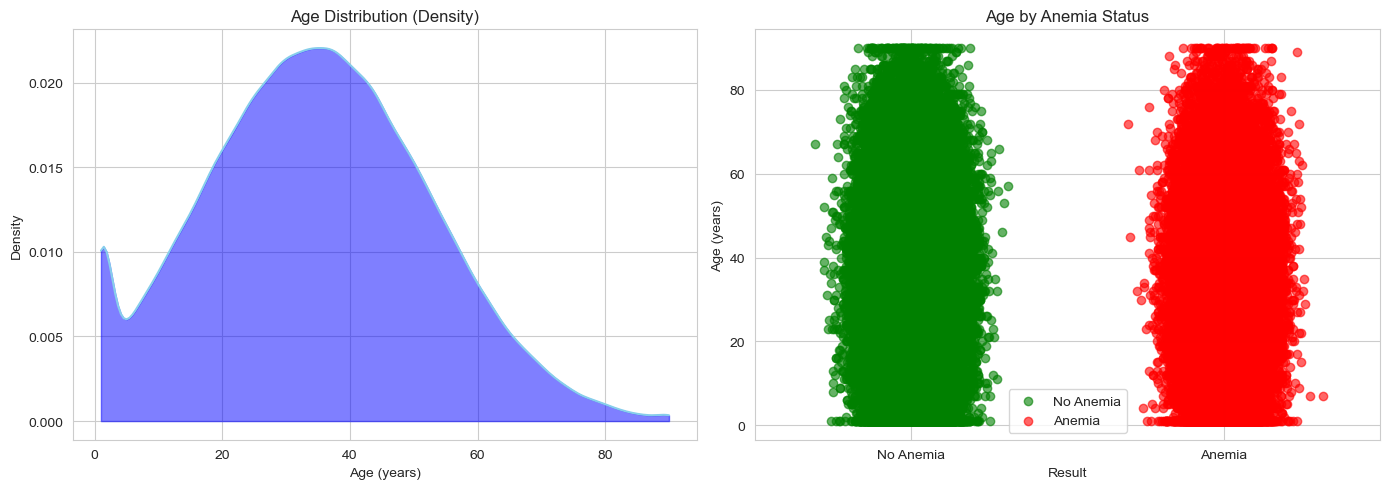

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
age_values = data['Age'].dropna()
density = gaussian_kde(age_values)
x = np.linspace(age_values.min(), age_values.max(), 200)
axes[0].plot(x, density(x), color='skyblue')
axes[0].fill_between(x, density(x), color='blue', alpha=0.5)
axes[0].set_title('Age Distribution (Density)')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Density')
 
age_no = data[data['Result'] == 0]['Age']
age_yes = data[data['Result'] == 1]['Age']
 
axes[1].scatter(np.random.normal(1, 0.07, size=len(age_no)), age_no, color='green', alpha=0.6, label='No Anemia')
axes[1].scatter(np.random.normal(2, 0.07, size=len(age_yes)), age_yes, color='red', alpha=0.6, label='Anemia')
axes[1].set_xticks([1, 2])
axes[1].set_xlim(0.5, 2.5)
axes[1].set_xticklabels(['No Anemia', 'Anemia'])
axes[1].set_title('Age by Anemia Status')
axes[1].set_xlabel('Result')
axes[1].set_ylabel('Age (years)')
axes[1].legend()
 
plt.tight_layout()
plt.show()

 ## **Coefficient Variation**

In [14]:
correlation_target = data.corr()['Result'].sort_values(ascending=False)
print("\nCorrelation with Target (Result):")
print(correlation_target)


Correlation with Target (Result):
Result                1.000000
TIBC(ug/dL)           0.347202
RDW(fL)               0.248246
MCHC(g/dL)            0.008947
Folate(ng/mL)         0.004848
Age                  -0.000243
CRP(mg/L)            -0.000280
Vitamin_B12(pg/mL)   -0.001078
WBC(10*3/uL)         -0.001577
MCV(fL)              -0.002427
MCH(pg)              -0.045734
Platelets(10*3/uL)   -0.059365
Gender               -0.095965
Ferritin(ng/mL)      -0.254056
Serum_Iron(ug/dL)    -0.269098
RBC(mil/uL)          -0.692084
Hematocrit(fL)       -0.727824
Hemoglobin(g/dL)     -0.774613
Name: Result, dtype: float64


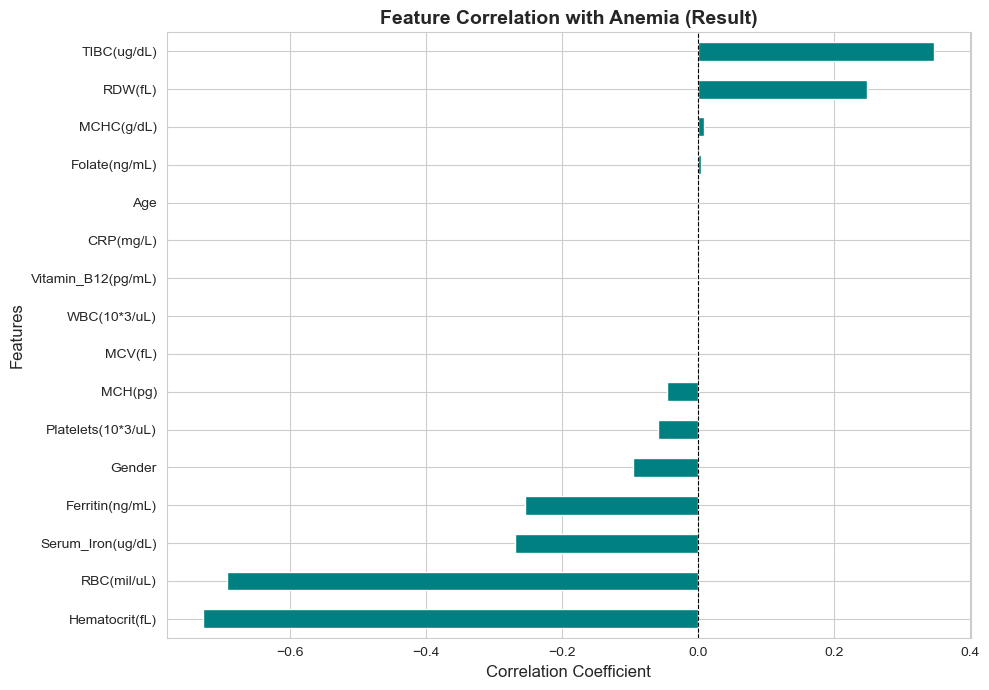

In [15]:
plt.figure(figsize=(10, 7))
correlation_target[1:-1].sort_values().plot(kind='barh', color='teal')
plt.title('Feature Correlation with Anemia (Result)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## **Correlation Heatmap**

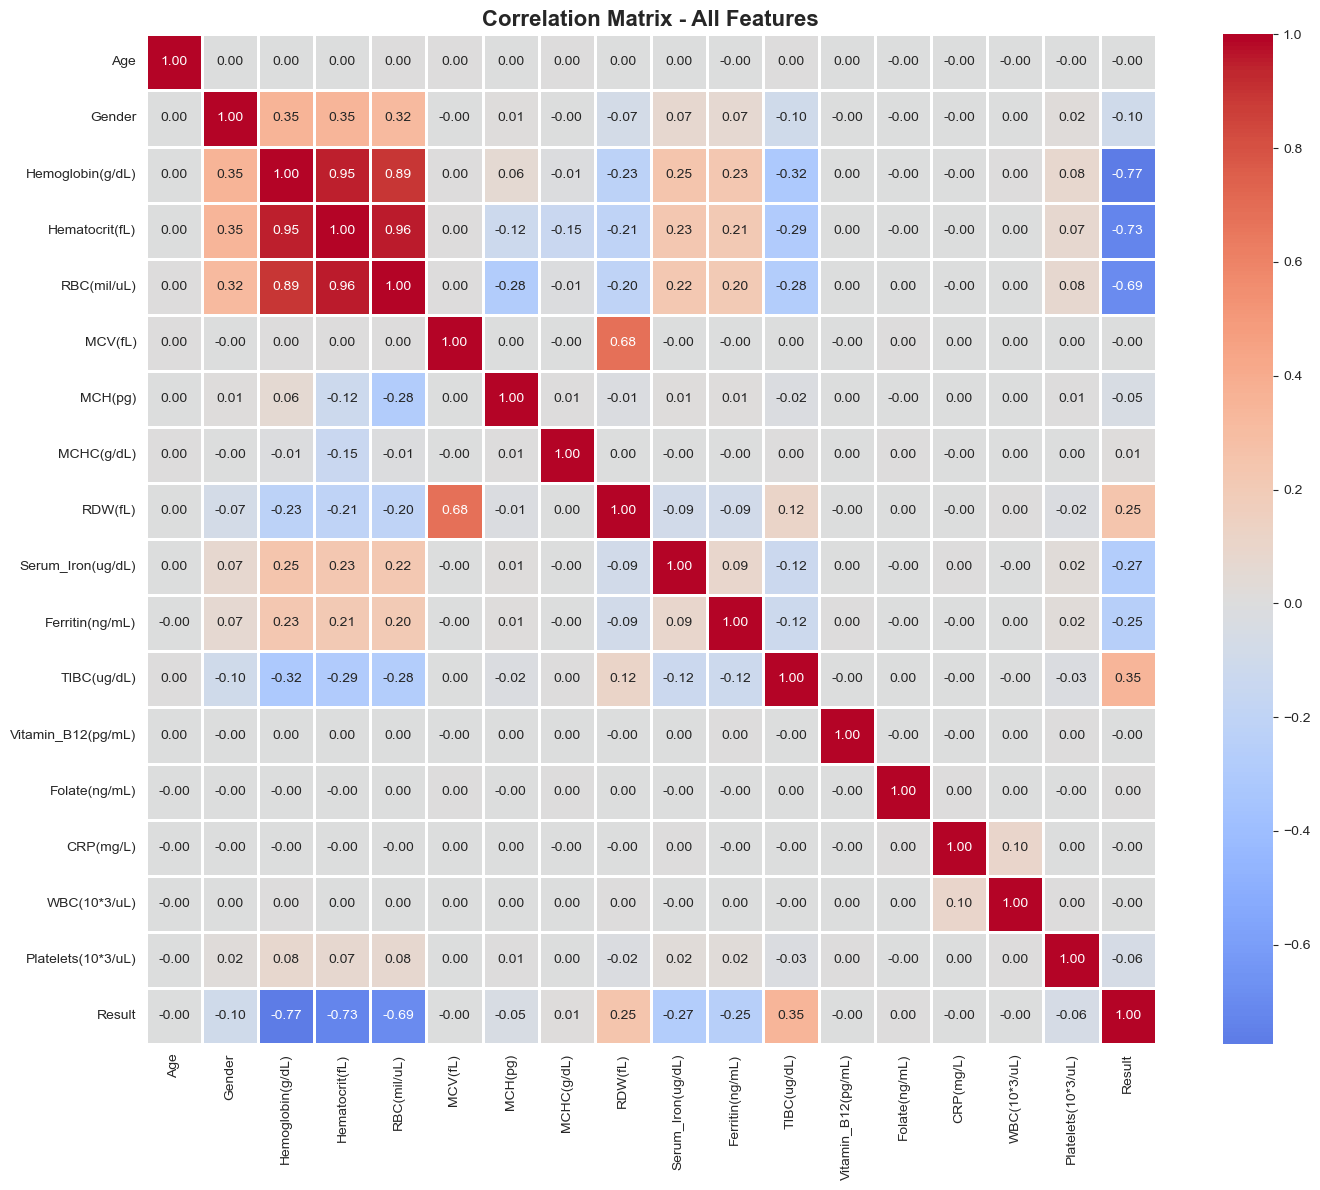

In [16]:
plt.figure(figsize=(15, 12))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Matrix - All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **Distribution Plots for Key Features**


Hemoglobin(g/dL):
             mean       std   min   max
Result                                 
0       14.278023  1.297436  12.0  18.0
1       10.826060  1.420833   6.0  13.0

Hematocrit(fL):
             mean       std     min       max
Result                                       
0       20.999189  4.189020  9.5316  39.27495
1       12.328127  3.249513  3.6000  23.66336

RBC(mil/uL):
            mean       std  min   max
Result                               
0       4.863970  0.548972  2.6  7.16
1       3.735939  0.580210  2.0  5.65

TIBC(ug/dL):
              mean        std    min    max
Result                                     
0       300.170241  39.752044  200.0  450.0
1       332.765243  45.686502  200.0  450.0

Ferritin(ng/mL):
              mean        std  min     max
Result                                    
0       131.342413  67.529765  5.0  400.00
1        94.333362  66.180537  5.0  388.89

Serum_Iron(ug/dL):
             mean        std   min     max
Result     

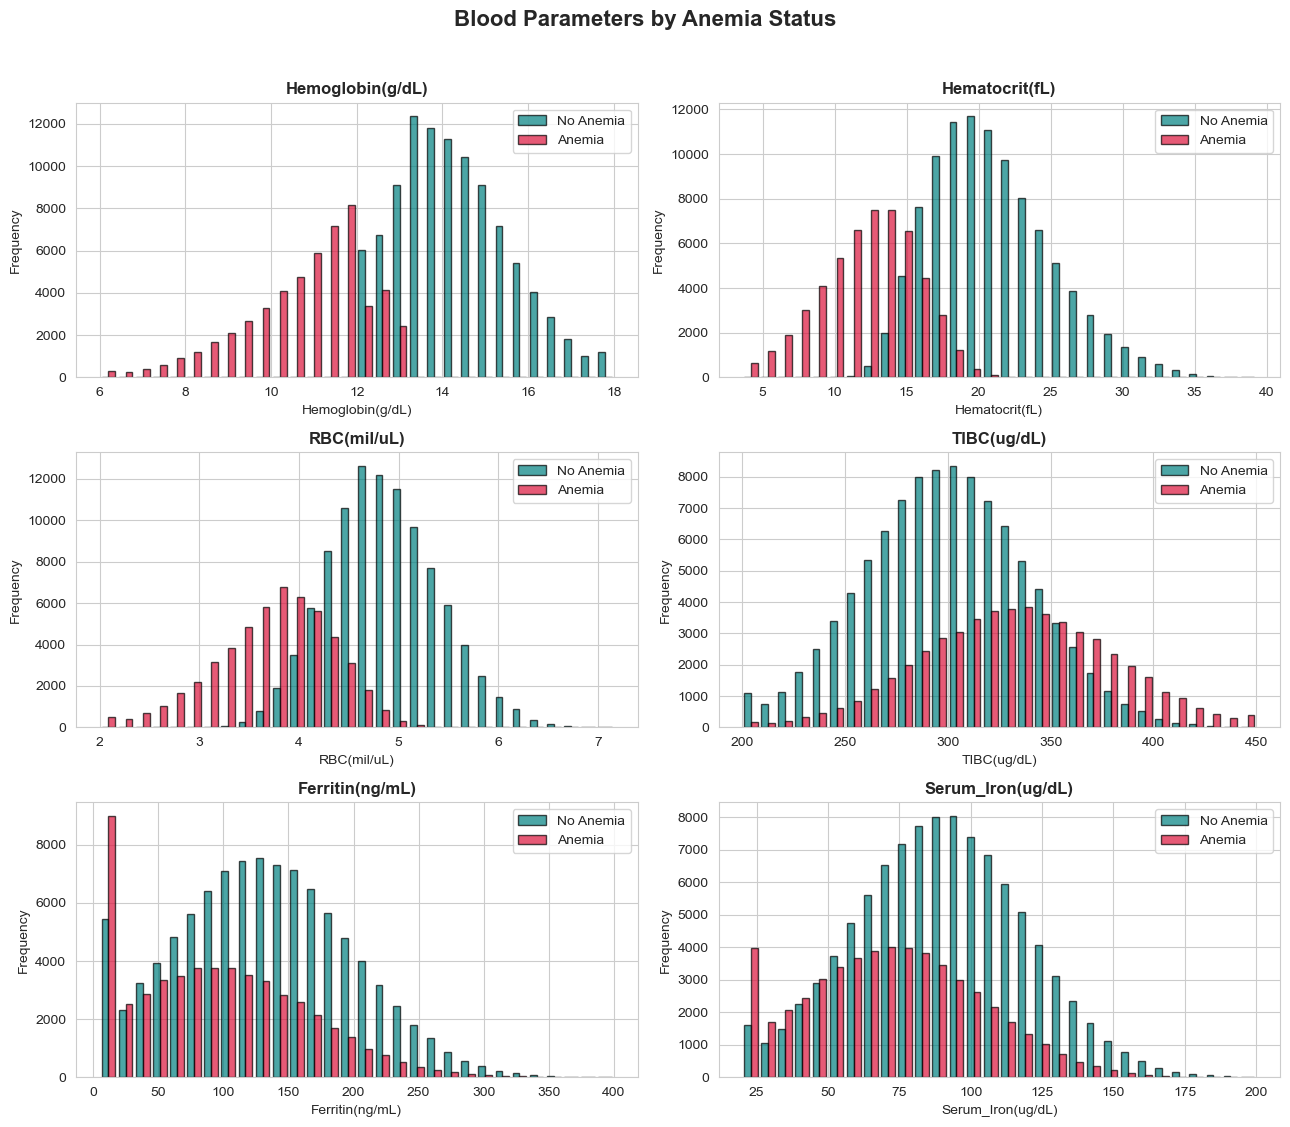

In [17]:
key_features = ['Hemoglobin(g/dL)', 'Hematocrit(fL)', 'RBC(mil/uL)', 'TIBC(ug/dL)', 'Ferritin(ng/mL)', 'Serum_Iron(ug/dL)']
 
for feature in key_features:
    print(f"\n{feature}:")
    print(data.groupby('Result')[feature].describe()[['mean', 'std', 'min', 'max']])
 
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
axes = axes.ravel()
 
for idx, feature in enumerate(key_features):
    feature_no = data[data['Result'] == 0][feature]
    feature_yes = data[data['Result'] == 1][feature]
 
    axes[idx].hist([feature_no, feature_yes], bins=30, color=['#008080', '#DC143C'],
                   label=['No Anemia', 'Anemia'], edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].legend()
 
plt.suptitle('Blood Parameters by Anemia Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Pairplots for Key Features**

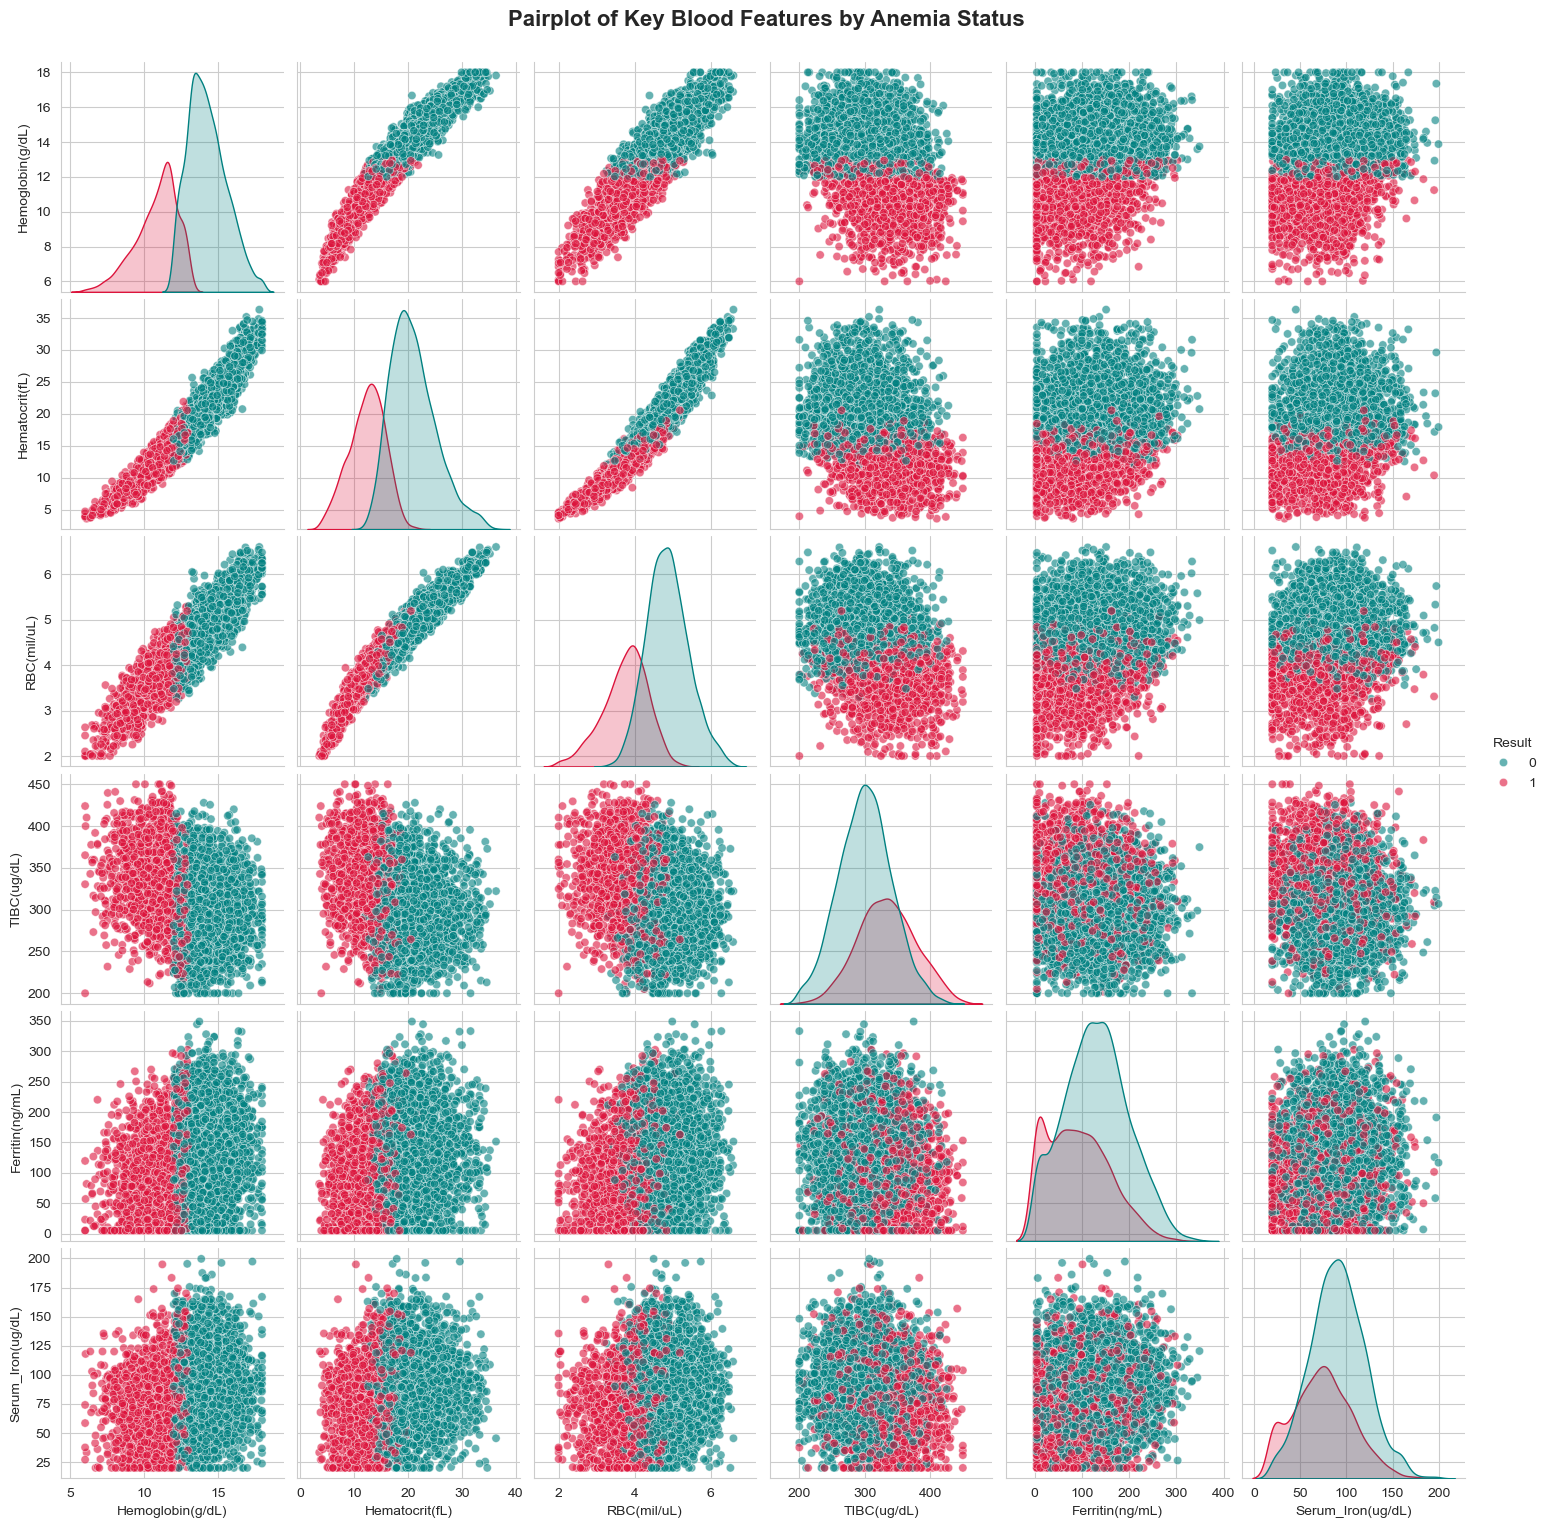

In [18]:
sample_data = data.sample(n=min(5000, len(data)), random_state=42)
key_features_with_target = key_features + ['Result']
 
sns.pairplot(sample_data[key_features_with_target], hue='Result',
             palette=['#008080', '#DC143C'], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Key Blood Features by Anemia Status', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## **Outlier Detection**

In [19]:
numeric_cols = data.select_dtypes(include=[np.number]).drop(columns=['Result', 'Gender'])
 
outlier_df = numeric_cols.apply(lambda x: (
    (x < x.quantile(0.25) - 1.5 * (x.quantile(0.75) - x.quantile(0.25))) |
    (x > x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))
).sum())
 
outlier_df = pd.DataFrame({'Count': outlier_df})
outlier_df['Percentage'] = (outlier_df['Count'] / len(data)) * 100
outlier_df = outlier_df.sort_values('Count', ascending=False)
print(outlier_df.head(10))  

                    Count  Percentage
CRP(mg/L)            7233    4.705063
MCH(pg)              1610    1.047304
Hemoglobin(g/dL)     1508    0.980953
RBC(mil/uL)          1377    0.895738
RDW(fL)              1275    0.829387
MCV(fL)              1037    0.674568
TIBC(ug/dL)           843    0.548371
WBC(10*3/uL)          604    0.392902
Hematocrit(fL)        543    0.353221
Platelets(10*3/uL)    494    0.321347


## **Feature Selection**

In [20]:
all_features = [
    'Hemoglobin(g/dL)', 'Hematocrit(fL)', 'RBC(mil/uL)',
    'TIBC(ug/dL)', 'RDW(fL)', 'Ferritin(ng/mL)',
    'Serum_Iron(ug/dL)', 'MCH(pg)', 'Platelets(10*3/uL)',
    'MCV(fL)', 'WBC(10*3/uL)', 'Vitamin_B12(pg/mL)',
    'Folate(ng/mL)', 'MCHC(g/dL)'
]
 
X = data[all_features]
y = data['Result']
 
print(f"Features selected: {len(all_features)}")
print(f"Feature list: {all_features}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Features selected: 14
Feature list: ['Hemoglobin(g/dL)', 'Hematocrit(fL)', 'RBC(mil/uL)', 'TIBC(ug/dL)', 'RDW(fL)', 'Ferritin(ng/mL)', 'Serum_Iron(ug/dL)', 'MCH(pg)', 'Platelets(10*3/uL)', 'MCV(fL)', 'WBC(10*3/uL)', 'Vitamin_B12(pg/mL)', 'Folate(ng/mL)', 'MCHC(g/dL)']

X shape: (153728, 14)
y shape: (153728,)


## **Train-Test Split and Feature Scaling**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")
 
results = {}

Training set size: (122982, 14)
Test set size: (30746, 14)


## **MODEL IMPLEMENTATION (SEPARATELY)**

## **1. Random Forest**

In [22]:
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
train_time = time.time() - start
 
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
 
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
 
results['Random Forest'] = {
    'Accuracy': acc_rf, 'Precision': prec_rf, 'Recall': rec_rf,
    'F1-Score': f1_rf, 'Training Time': train_time
}
 
print(f"Random Forest Results:")
print(f"Accuracy:      {acc_rf:.4f}")
print(f"Precision:     {prec_rf:.4f}")
print(f"Recall:        {rec_rf:.4f}")
print(f"F1-Score:      {f1_rf:.4f}")
print(f"Training Time: {train_time:.2f}s")

Random Forest Results:
Accuracy:      0.9348
Precision:     0.9851
Recall:        0.8246
F1-Score:      0.8977
Training Time: 7.08s


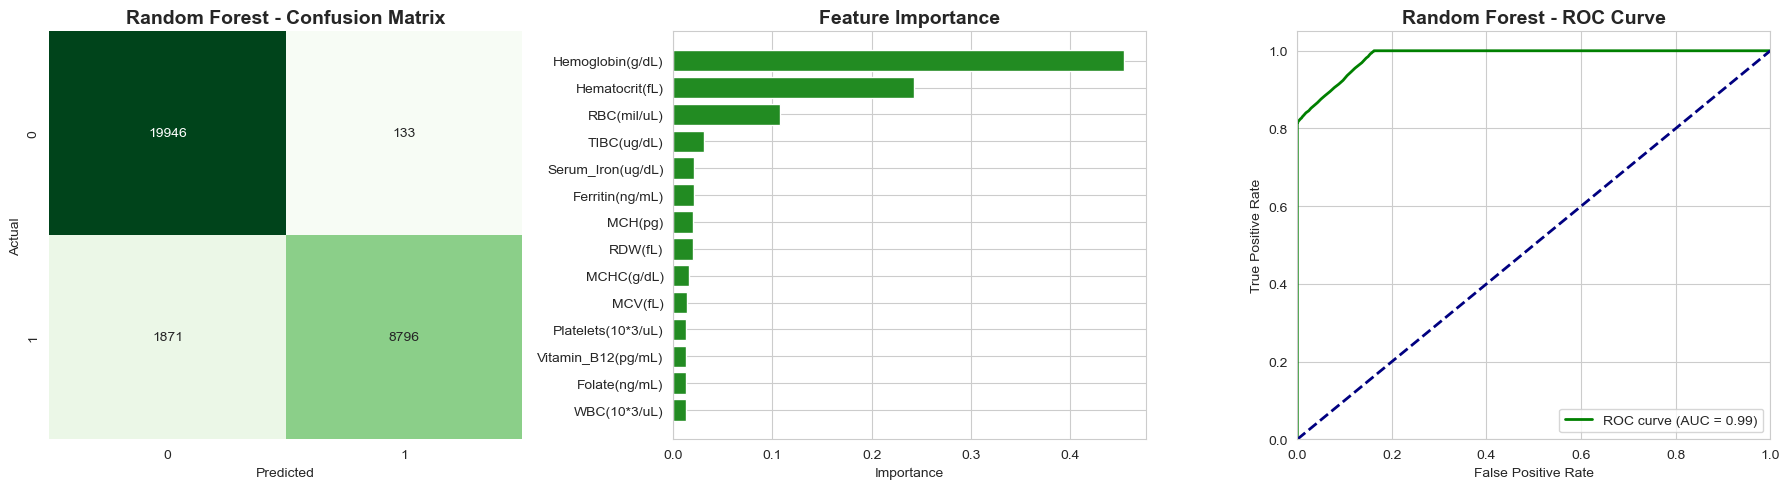

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False)
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
 
feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
axes[1].barh(feature_importance['Feature'], feature_importance['Importance'], color='forestgreen')
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
 
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
axes[2].plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.2f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Random Forest - ROC Curve', fontsize=14, fontweight='bold')
axes[2].legend(loc="lower right")
 
plt.tight_layout()
plt.show()

## **2. XGBoost**

In [24]:
start = time.time()
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)
train_time = time.time() - start
 
y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
 
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
 
results['XGBoost'] = {
    'Accuracy': acc_xgb, 'Precision': prec_xgb, 'Recall': rec_xgb,
    'F1-Score': f1_xgb, 'Training Time': train_time
}
 
print(f"XGBoost Results:")
print(f"Accuracy:      {acc_xgb:.4f}")
print(f"Precision:     {prec_xgb:.4f}")
print(f"Recall:        {rec_xgb:.4f}")
print(f"F1-Score:      {f1_xgb:.4f}")
print(f"Training Time: {train_time:.2f}s")

XGBoost Results:
Accuracy:      0.9283
Precision:     0.9438
Recall:        0.8434
F1-Score:      0.8908
Training Time: 1.02s


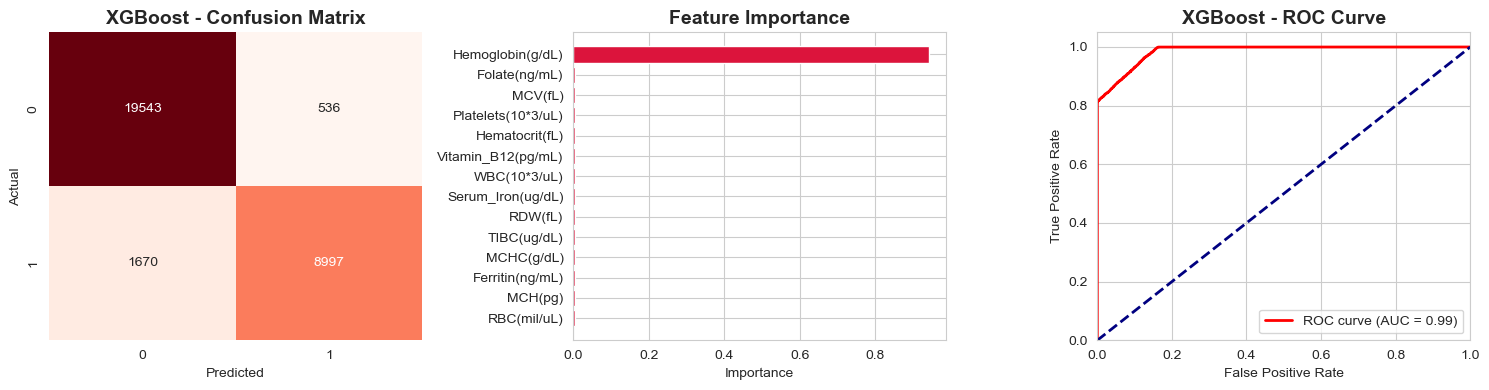

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar=False)
axes[0].set_title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
 
feature_importance_xgb = pd.DataFrame({
    'Feature': all_features,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)
axes[1].barh(feature_importance_xgb['Feature'], feature_importance_xgb['Importance'], color='crimson')
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
 
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
axes[2].plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc_xgb:.2f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('XGBoost - ROC Curve', fontsize=14, fontweight='bold')
axes[2].legend(loc="lower right")
 
plt.tight_layout()
plt.show()

## **Model Comparison**

               Accuracy  Precision    Recall  F1-Score  Training Time
Random Forest  0.934821   0.985105  0.824599  0.897734       7.076544
XGBoost        0.928251   0.943774  0.843442  0.890792       1.020638

BEST MODEL: Random Forest
   F1-Score: 0.8977
   Accuracy: 0.9348


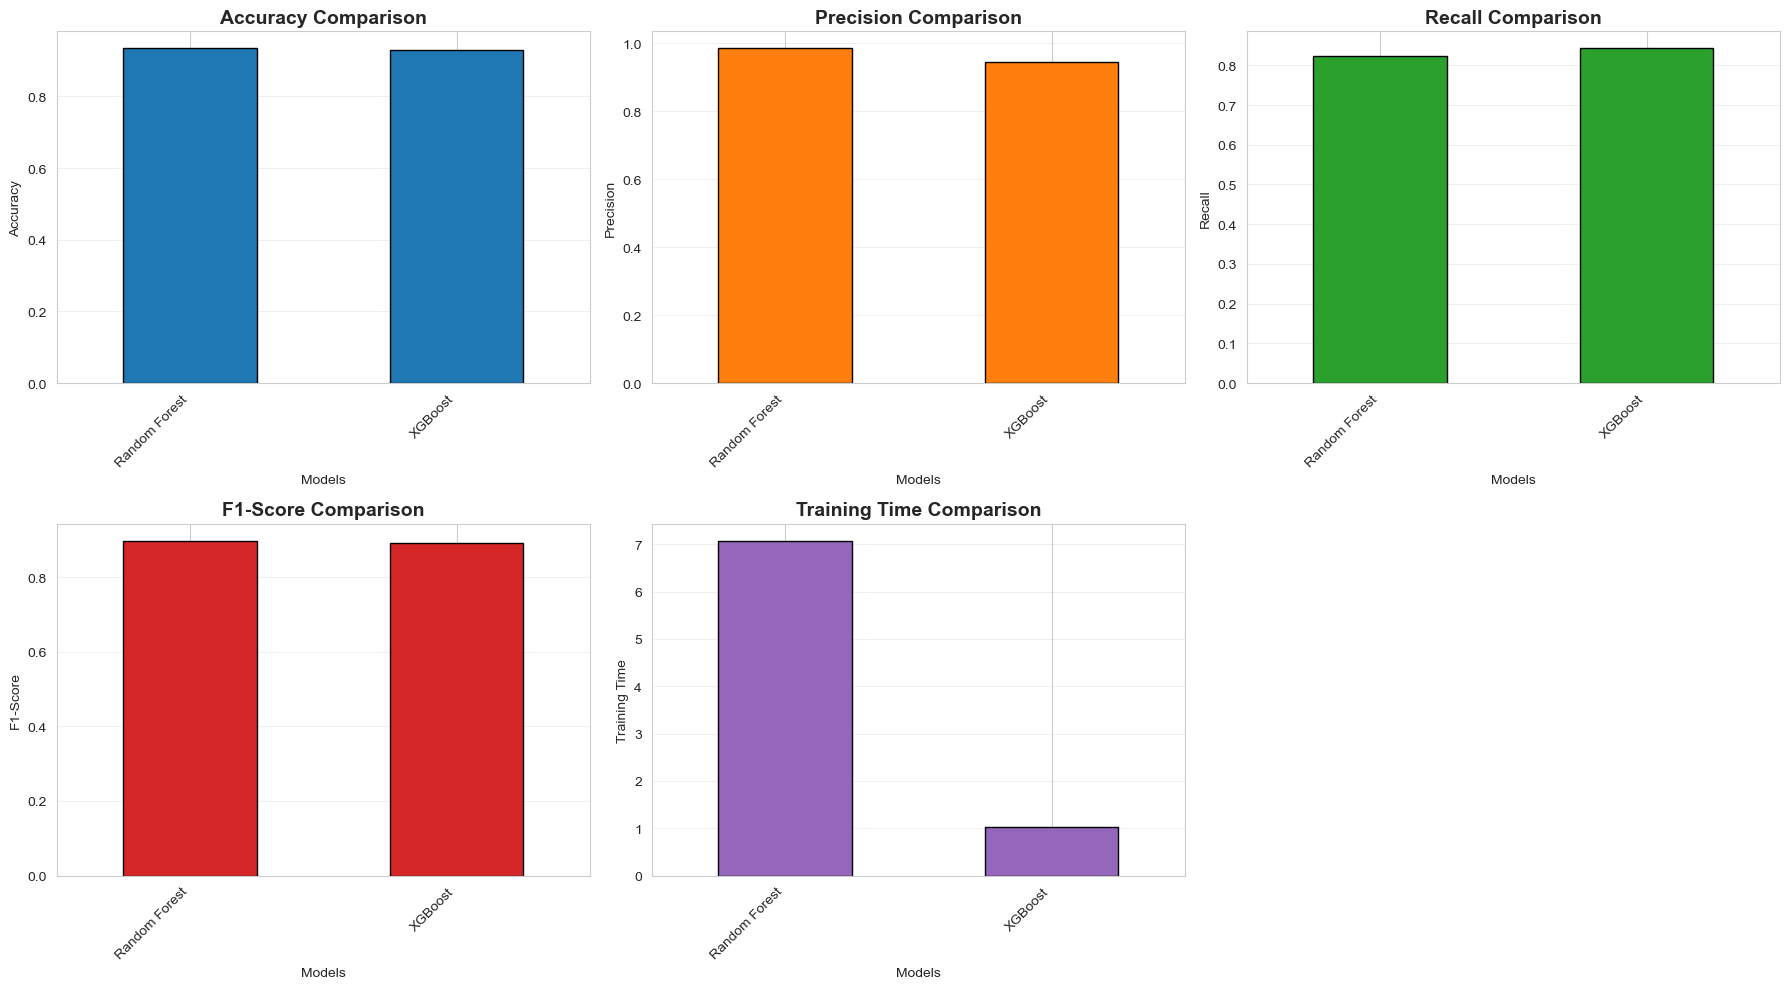

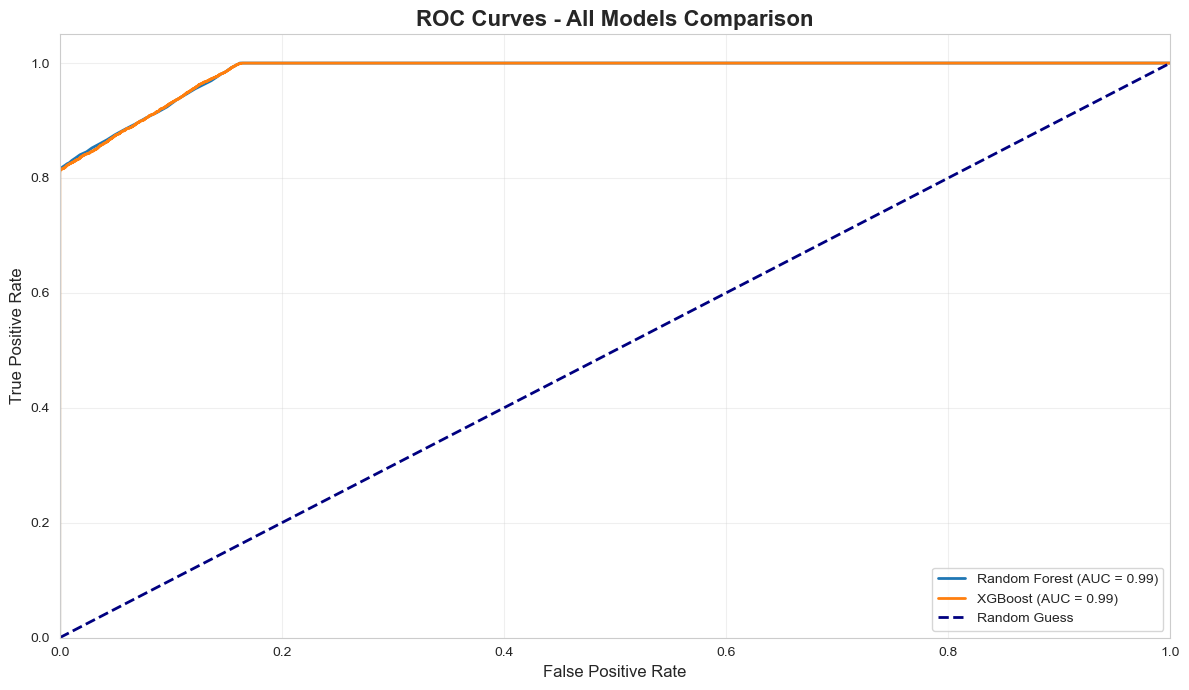

In [26]:
results_df = pd.DataFrame(results).T
print(results_df)
 
best_model = results_df['F1-Score'].idxmax()
print(f"\nBEST MODEL: {best_model}")
print(f"   F1-Score: {results_df.loc[best_model, 'F1-Score']:.4f}")
print(f"   Accuracy: {results_df.loc[best_model, 'Accuracy']:.4f}")
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
 
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    results_df[metric].plot(kind='bar', ax=ax, color=colors[idx], edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xlabel('Models')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
 
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()
 
plt.figure(figsize=(12, 7))
axes_roc = plt.gca()
axes_roc.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
axes_roc.plot(fpr_xgb, tpr_xgb, lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
axes_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
axes_roc.set_xlim([0.0, 1.0])
axes_roc.set_ylim([0.0, 1.05])
axes_roc.set_xlabel('False Positive Rate', fontsize=12)
axes_roc.set_ylabel('True Positive Rate', fontsize=12)
axes_roc.set_title('ROC Curves - All Models Comparison', fontsize=16, fontweight='bold')
axes_roc.legend(loc="lower right", fontsize=10)
axes_roc.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Save models**

In [31]:
import joblib
joblib.dump(rf, 'rf_model.pkl')
joblib.dump(xgb, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Models saved successfully!")

Models saved successfully!
